In [1]:
#import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load data

df = pd.read_csv("aqi_health_final.csv")
print(df.head())
print(df.shape)
print(df.info())

    city        date  aqi  temperature  humidity  respiratory_cases  \
0  Delhi  2025-01-01  339         23.2        53               5809   
1  Delhi  2025-02-01  335         22.1        58               5497   
2  Delhi  2025-03-01  286         37.1        44               5366   
3  Delhi  2025-04-01  293         36.0        37               5461   
4  Delhi  2025-05-01  274         35.4        33               5233   

     aqi_category     month  month_number  season  health_risk_score  
0       Hazardous   January             1  Winter             25.270  
1       Hazardous  February             2  Winter             23.998  
2  Very Unhealthy     March             3  Summer             23.180  
3  Very Unhealthy     April             4  Summer             23.602  
4  Very Unhealthy       May             5  Summer             22.576  
(120, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column             Non-Null

In [4]:
#Missing values

print(df.isnull().sum())

city                 0
date                 0
aqi                  0
temperature          0
humidity             0
respiratory_cases    0
aqi_category         0
month                0
month_number         0
season               0
health_risk_score    0
dtype: int64


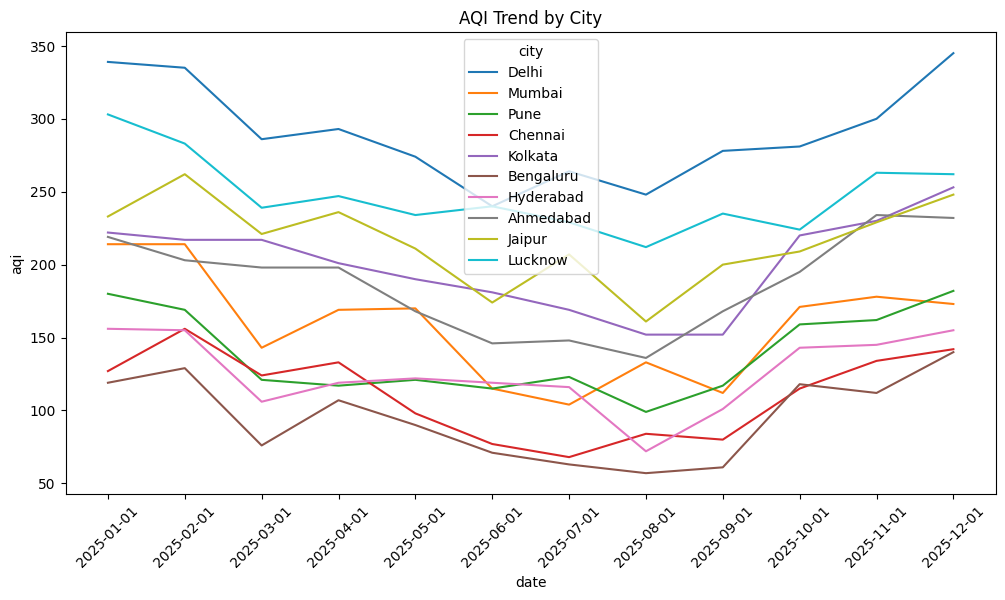

In [22]:
#AQI Trend Over Time

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="date", y="aqi", hue="city")
plt.title("AQI Trend by City")
plt.xticks(rotation=45)
plt.show()

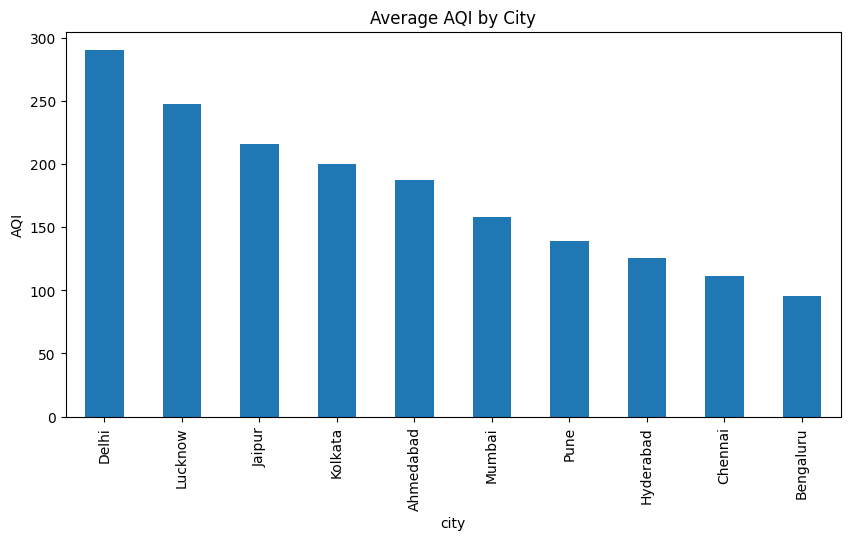

In [23]:
#Top Polluted Cities

city_aqi = df.groupby("city")["aqi"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
city_aqi.plot(kind="bar")
plt.title("Average AQI by City")
plt.ylabel("AQI")
plt.show()

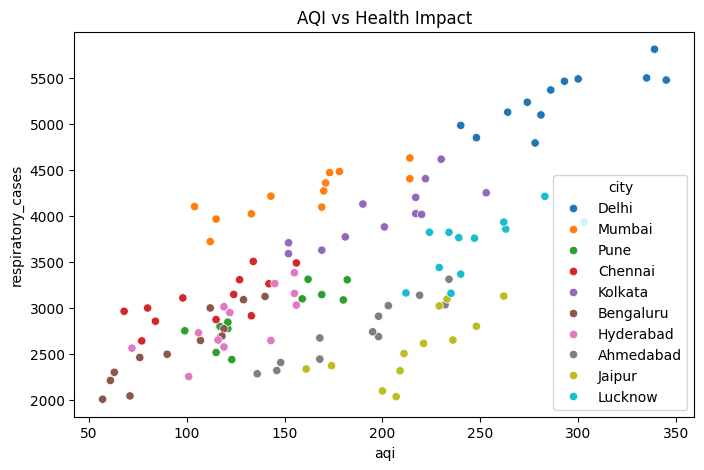

In [10]:
#AQI vs Respiratory Cases

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="aqi", y="respiratory_cases", hue="city")
plt.title("AQI vs Health Impact")
plt.show()

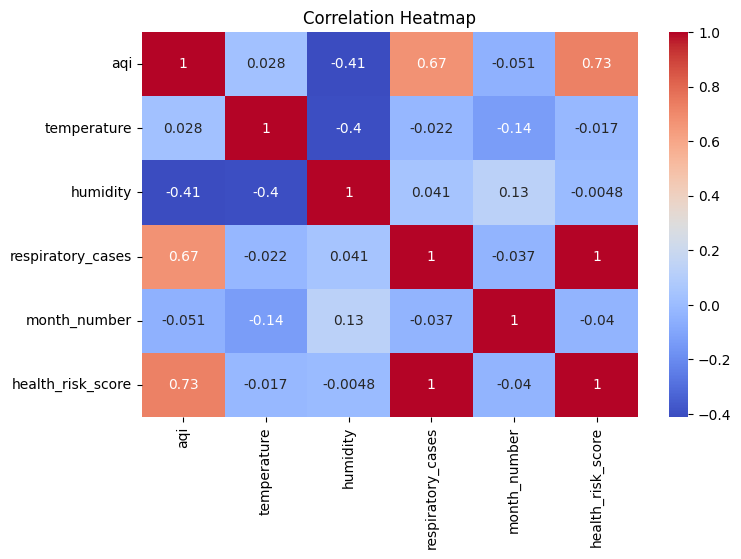

In [11]:
#Correlation Heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

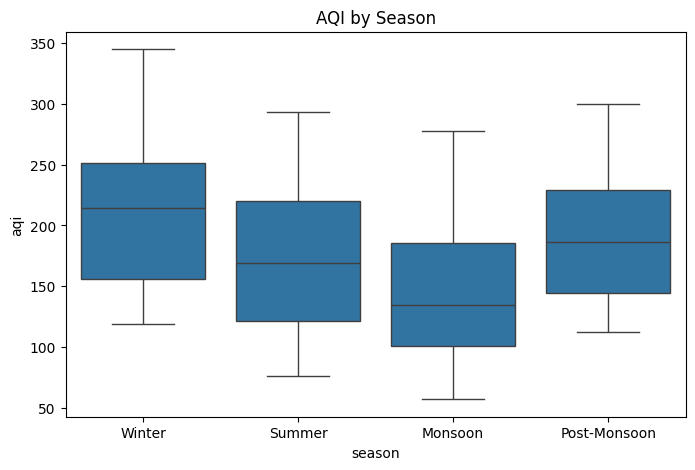

In [12]:
#Seasonal AQI Analysis

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="season", y="aqi")
plt.title("AQI by Season")
plt.show()

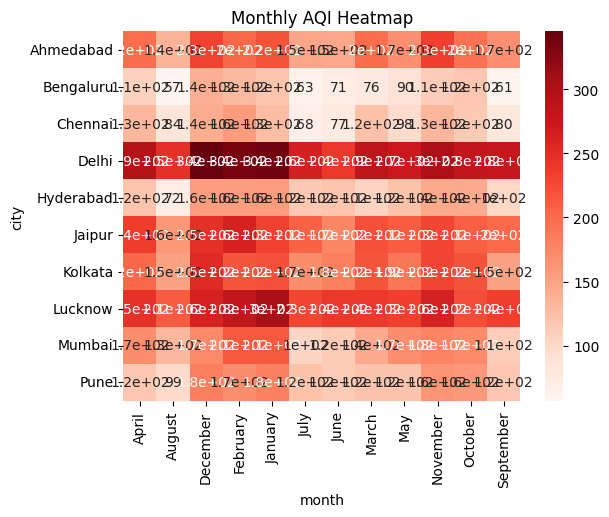

In [25]:
#Monthly Heatmap

pivot = df.pivot_table(values="aqi", index="city", columns="month", aggfunc="mean")
sns.heatmap(pivot, cmap="Reds", annot=True)
plt.title("Monthly AQI Heatmap")
plt.show()

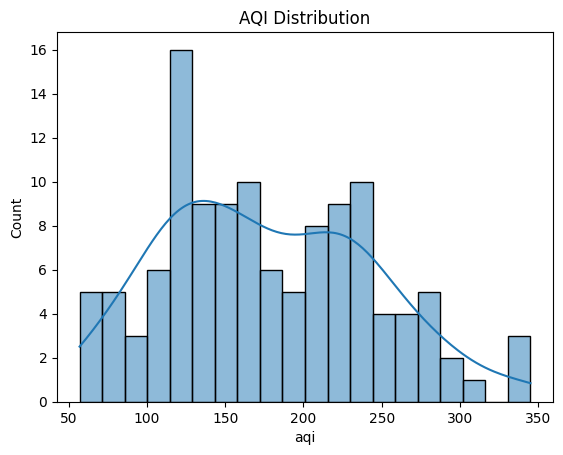

In [16]:
#Distribution Plot

sns.histplot(df["aqi"], bins=20, kde=True)
plt.title("AQI Distribution")
plt.show()

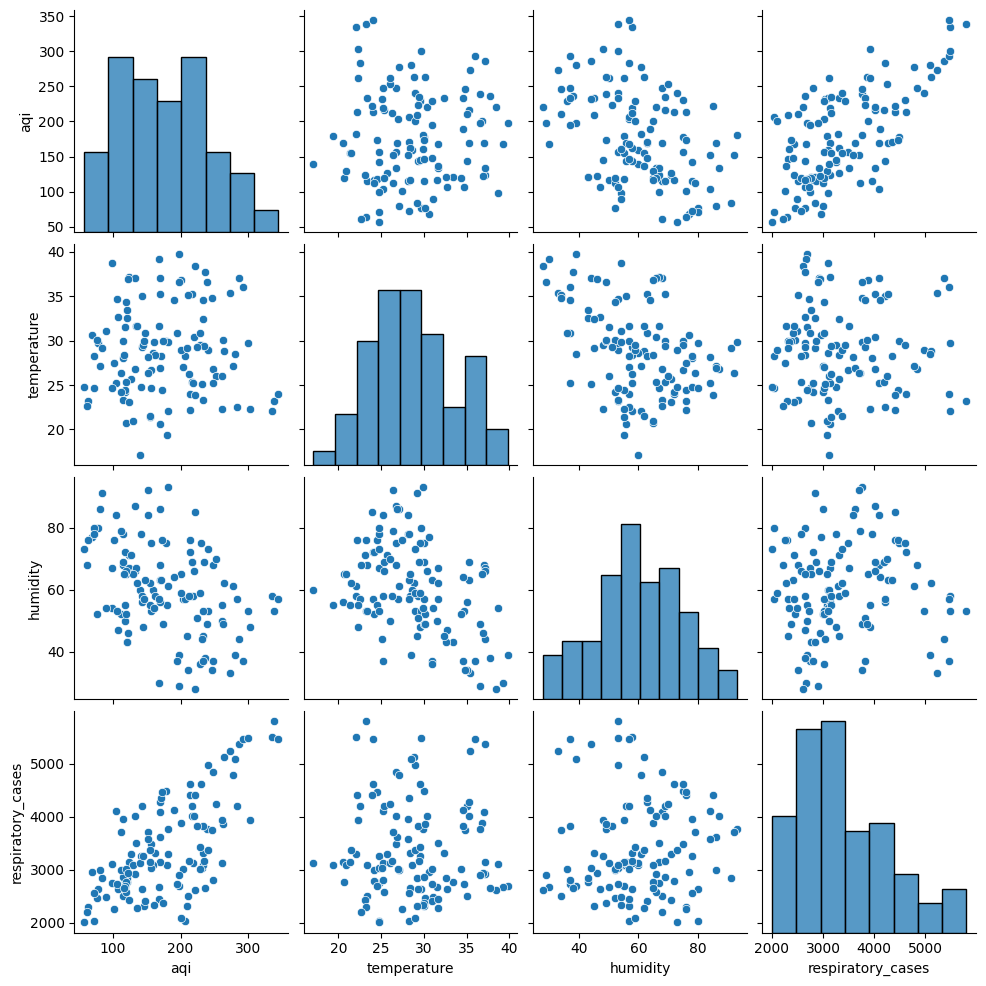

In [17]:
#pairplot

sns.pairplot(df[["aqi","temperature","humidity","respiratory_cases"]])
plt.show()

In [13]:
#Insights

print("Highest AQI City:", df.groupby("city")["aqi"].mean().idxmax())
print("Lowest AQI City:", df.groupby("city")["aqi"].mean().idxmin())
print("Avg AQI:", df["aqi"].mean())
print("Total Cases:", df["respiratory_cases"].sum())

Highest AQI City: Delhi
Lowest AQI City: Bengaluru
Avg AQI: 177.04166666666666
Total Cases: 406906
